In [36]:
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
crop=pd.read_csv("Crop_recommendation_renamed.csv")
print(crop.head())

    N   P   K  temperature   humidity        ph    rainfall  Season  Crop
0  90  42  43    20.879744  82.002744  6.502985  202.935536  Kharif  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  Kharif  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  Kharif  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  Kharif  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  Kharif  rice


In [2]:
print(crop.iloc[90:100])

     N   P   K  temperature   humidity        ph    rainfall  Season  Crop
90  93  53  38    26.929951  81.914112  7.069172  290.679378  Kharif  rice
91  90  44  38    23.835095  83.883871  7.473134  241.201351  Kharif  rice
92  81  45  35    26.528728  80.122675  6.158377  218.916357  Kharif  rice
93  78  40  38    26.464283  83.856427  7.549874  248.225649  Kharif  rice
94  60  51  36    22.696578  82.810889  6.028322  256.996476  Kharif  rice
95  88  46  42    22.683191  83.463583  6.604993  194.265172  Kharif  rice
96  93  47  37    21.533463  82.140041  6.500343  295.924880  Kharif  rice
97  60  55  45    21.408658  83.329319  5.935745  287.576694  Kharif  rice
98  78  35  44    26.543481  84.673536  7.072656  183.622266  Kharif  rice
99  65  37  40    23.359054  83.595123  5.333323  188.413665  Kharif  rice


In [3]:
crop.isnull()

,N,P,K,temperature,humidity,ph,rainfall,Season,Crop
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
6495,False,False,False,False,False,False,False,False,False
6496,False,False,False,False,False,False,False,False,False
6497,False,False,False,False,False,False,False,False,False
6498,False,False,False,False,False,False,False,False,False


In [4]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Season         0
Crop           0
dtype: int64

In [5]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Season         0
Crop           0
dtype: int64

In [6]:
print(crop.tail())

        N   P   K  temperature   humidity        ph    rainfall     Season  \
6495  112  37  39    22.982210  75.219993  6.723113   79.853858  Perennial   
6496  127  28  61    26.109456  86.286618  6.908413   89.081750  Perennial   
6497  123  35  30    28.162558  86.393183  6.774557  144.394635  Perennial   
6498   91  30  39    22.726952  79.142237  6.738635   84.303859  Perennial   
6499  121  33  38    24.165925  76.015777  7.127096  122.338714  Perennial   

           Crop  
6495  sugarcane  
6496  sugarcane  
6497  sugarcane  
6498  sugarcane  
6499  sugarcane  


In [7]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000
mean,74.913846,53.746308,47.146154,23.911684,67.783767,6.622534,105.402654
std,37.300012,14.994807,22.712237,6.235788,12.136021,0.510603,55.183365
min,0.000000,20.000000,15.000000,10.002694,14.258040,4.548202,36.120429
25%,42.000000,43.000000,29.000000,18.886633,61.402519,6.250507,68.598202
50%,70.000000,53.000000,43.000000,24.081626,67.075902,6.586444,87.077932
75%,103.000000,64.000000,60.000000,28.998461,75.247826,6.951447,122.838805
max,151.000000,91.000000,111.000000,36.977944,94.974781,8.868741,299.975156


In [8]:
crop.corr(numeric_only=True)

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.381362,0.498357,-0.095690,0.106720,-0.223426,-0.144412
P,-0.381362,1.000000,0.049726,-0.351274,-0.214207,0.090420,0.008793
K,0.498357,0.049726,1.000000,-0.269259,-0.010438,-0.205284,-0.088112
temperature,-0.095690,-0.351274,-0.269259,1.000000,0.121265,-0.094985,0.255776
humidity,0.106720,-0.214207,-0.010438,0.121265,1.000000,-0.013923,0.409988
ph,-0.223426,0.090420,-0.205284,-0.094985,-0.013923,1.000000,-0.036727
rainfall,-0.144412,0.008793,-0.088112,0.255776,0.409988,-0.036727,1.000000


<Axes: >

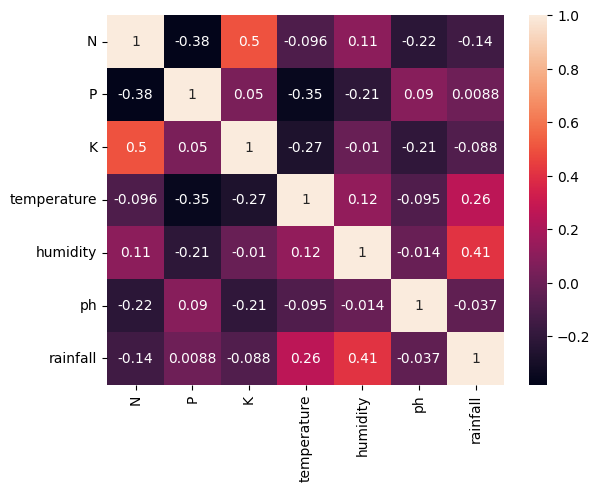

In [9]:
import seaborn as sns
sns.heatmap(crop.corr(numeric_only=True), annot=True, cbar=True)


In [10]:
crop.Season.value_counts()


Season
Kharif       3000
Rabi         3000
Perennial     500
Name: count, dtype: int64

In [11]:
crop.Crop.value_counts()

Crop
rice          500
maize         500
chickpea      500
pigeonpeas    500
mungbean      500
cotton        500
wheat         500
soybean       500
potato        500
onion         500
garlic        500
peas          500
sugarcane     500
Name: count, dtype: int64

In [12]:
crop["Crop"].unique().size

13

C:\Users\Dell\AppData\Local\Temp\ipykernel_9828\3466690695.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(crop["N"])


<function matplotlib.pyplot.show(close=None, block=None)>

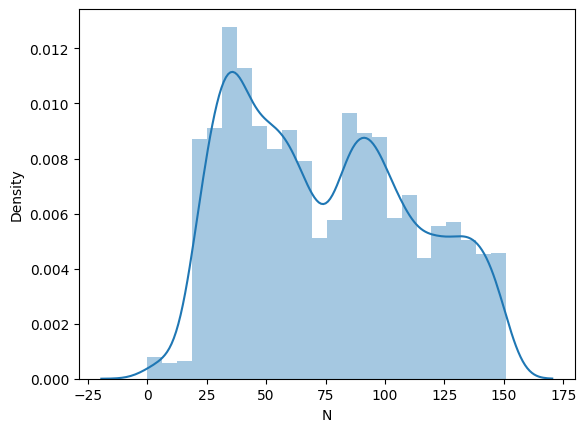

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.distplot(crop["N"])
plt.show


C:\Users\Dell\AppData\Local\Temp\ipykernel_9828\832531294.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(crop["P"])


<function matplotlib.pyplot.show(close=None, block=None)>

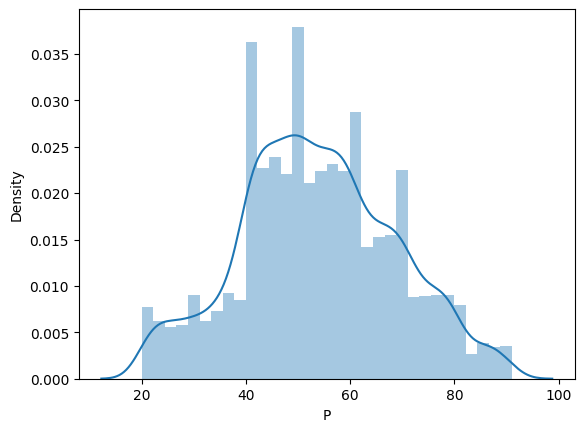

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.distplot(crop["P"])
plt.show

C:\Users\Dell\AppData\Local\Temp\ipykernel_9828\3722457221.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(crop["K"])


<function matplotlib.pyplot.show(close=None, block=None)>

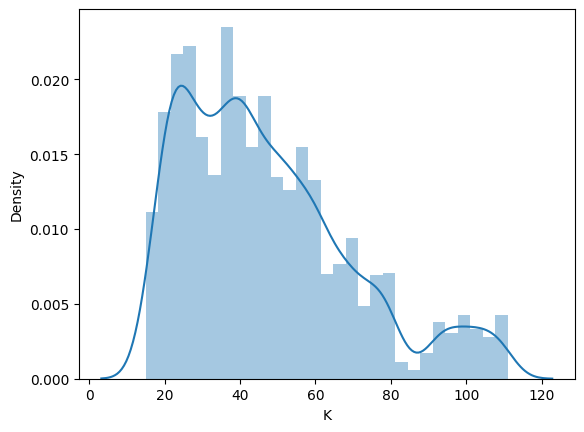

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.distplot(crop["K"])
plt.show

In [16]:
Q1 = crop['K'].quantile(0.25)
Q3 = crop['K'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = crop[(crop['K'] < lower) | (crop['K'] > upper)]
print(outliers)

        N   P    K  temperature   humidity        ph   rainfall Season    Crop
804   135  41  110    16.741933  74.616589  6.293407  83.577922   Rabi  potato
805   132  43  107    24.607806  63.123277  5.685228  54.646457   Rabi  potato
806   147  50  107    19.159074  64.691226  6.417752  62.852363   Rabi  potato
817   122  41  108    21.061887  62.262196  6.293744  67.316088   Rabi  potato
824   132  50  109    18.838472  71.543705  5.755645  58.088211   Rabi  potato
...   ...  ..  ...          ...        ...       ...        ...    ...     ...
4888  120  40  109    18.474696  70.080904  6.074504  51.551422   Rabi  potato
4890  124  45  108    19.458773  67.849796  6.162949  69.816533   Rabi  potato
4891  147  43  108    15.814409  77.935562  6.002402  63.193244   Rabi  potato
4895  149  42  111    21.966669  60.898401  5.893610  74.189662   Rabi  potato
4896  128  49  110    23.411887  71.133812  6.347618  84.861657   Rabi  potato

[113 rows x 9 columns]


In [17]:
crop.Crop.unique()


array(['rice', 'maize', 'chickpea', 'pigeonpeas', 'mungbean', 'cotton',
       'wheat', 'soybean', 'potato', 'onion', 'garlic', 'peas',
       'sugarcane'], dtype=object)

In [18]:
crop_dict={
    'rice':1,
    "maize":2,
    "chickpea":3,
    "pigeonpeas":4,
    "mungbean":5,
    "cotton":6,
    "wheat":7,
    "soybean":8,
    "potato":9,
    "onion":10,
    "garlic":11,
    "peas":12,
    "sugarcane":13
}
crop["Crop"]=crop["Crop"].map(crop_dict)

In [19]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,Season,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Kharif,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Kharif,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Kharif,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Kharif,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Kharif,1


In [20]:
crop.Crop.value_counts()

Crop
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
10    500
11    500
12    500
13    500
Name: count, dtype: int64

In [21]:
X=crop.drop(columns=["Season","Crop"], axis=1, errors="ignore")
Y=crop["Crop"]

In [22]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [23]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: Crop, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y, test_size=0.2, random_state=42)

In [25]:
X_train.shape

(5200, 7)

In [26]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
889,149,43,101,15.173798,73.401921,5.670478,81.659481
4385,33,54,57,31.193693,63.949218,6.851816,142.273648
4919,35,61,33,23.134746,78.371470,6.378089,82.939009
4794,136,49,111,16.017184,64.401354,5.729839,85.003209
5438,110,52,47,22.973309,59.294876,6.341558,57.912978
...,...,...,...,...,...,...,...
3772,74,48,38,23.503588,59.319165,6.748491,80.595695
5191,34,52,30,22.584915,67.793366,6.321516,118.276241
5226,54,61,31,13.917668,71.707844,7.407128,98.556600
5390,110,52,52,13.845853,64.346075,6.287399,95.374100


In [27]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
3106,48,38,20,31.301856,68.299180,6.883777,62.673457
6161,136,41,31,21.209098,77.625496,7.277241,114.126947
1867,61,48,26,27.620350,70.680119,6.067094,82.245316
3238,26,38,27,30.032047,68.871420,6.107011,77.102099
5509,88,41,40,16.424027,50.481553,6.821746,53.029846
...,...,...,...,...,...,...,...
1770,82,49,29,31.422782,68.277431,6.329975,81.101474
1608,94,41,59,21.370528,90.517163,6.541204,226.102839
2191,49,72,42,16.002414,69.565390,7.714210,65.725879
624,92,41,41,16.616287,60.812702,6.757879,65.476381


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score

In [29]:
models={
    "LogisticRegression":LogisticRegression(),
    "GaussianNB":GaussianNB(),
    "SVC":SVC(),
    "KNeighborsClassifier":KNeighborsClassifier(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "ExtraTreeClassifier":ExtraTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier(),
    "BaggingClassifier":BaggingClassifier(),
    "GradientBoostingClassifier":GradientBoostingClassifier(),
    "AdaBoostClassifier":AdaBoostClassifier()
}

In [30]:
for name, model in models.items():
    model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
    score=accuracy_score(Y_test,Y_pred)
    print(f"{name} model with accuracy : {score}")

C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression model with accuracy : 0.8992307692307693
GaussianNB model with accuracy : 0.9446153846153846
SVC model with accuracy : 0.9292307692307692
KNeighborsClassifier model with accuracy : 0.9384615384615385
DecisionTreeClassifier model with accuracy : 0.9661538461538461
ExtraTreeClassifier model with accuracy : 0.8623076923076923
RandomForestClassifier model with accuracy : 0.98
BaggingClassifier model with accuracy : 0.97
GradientBoostingClassifier model with accuracy : 0.9784615384615385
AdaBoostClassifier model with accuracy : 0.40615384615384614


In [31]:
from sklearn.preprocessing import MinMaxScaler
mx=MinMaxScaler()
X_train=mx.fit_transform(X_train)
X_test=mx.transform(X_test)

In [32]:
print("dtypes:\n", X.dtypes)
print("\nNon-numeric columns in X:", X.select_dtypes(include=['object','category']).columns.tolist())
print("\nUnique counts per column:\n", X.nunique())
const_cols = [c for c in X.columns if X[c].nunique() <= 1]
print("Constant columns (<=1 unique):", const_cols)

dtypes:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
dtype: object

Non-numeric columns in X: []

Unique counts per column:
 N               150
P                72
K                93
temperature    6500
humidity       6500
ph             6500
rainfall       6500
dtype: int64
Constant columns (<=1 unique): []


In [33]:
X_train

array([[0.98675497, 0.32394366, 0.89583333, ..., 0.73270612, 0.26019096,
        0.17259138],
       [0.21854305, 0.47887324, 0.4375    , ..., 0.61555664, 0.53407494,
        0.40231691],
       [0.23178808, 0.57746479, 0.1875    , ..., 0.79429486, 0.42424511,
        0.17744075],
       ...,
       [0.35761589, 0.57746479, 0.16666667, ..., 0.71171104, 0.6628198 ,
        0.23663086],
       [0.72847682, 0.45070423, 0.38541667, ..., 0.62047497, 0.4032194 ,
        0.2245693 ],
       [0.92715232, 0.28169014, 0.85416667, ..., 0.69065572, 0.28208093,
        0.09667115]], shape=(5200, 7))

In [34]:
# ===== RE-TRAIN (run this cell now) =====
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Build X,y (drop Season & Crop)
X = crop.drop(columns=['Crop','Season'], errors='ignore')
y = crop['Crop']

# ensure numeric and fill
X = X.apply(pd.to_numeric, errors='coerce').fillna(X.median())

# encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# fit scaler on TRAIN only (very important)
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)

# train model ONCE
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# quick checks
print("X.columns:", X.columns.tolist())
print("Scaler mean_ (first 7):", sc.mean_)
print("LabelEncoder classes sample:", le.classes_[:10])
print("Train acc:", model.score(X_train_scaled, y_train))
print("Test  acc:", model.score(X_test_scaled, y_test))

X.columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Scaler mean_ (first 7): [ 74.91        53.84615385  47.08134615  23.90092549  67.82936939
   6.61872548 105.48426922]
LabelEncoder classes sample: [ 1  2  3  4  5  6  7  8  9 10]
Train acc: 1.0
Test  acc: 0.9753846153846154


In [35]:
print("X.columns order:", X.columns.tolist())

X.columns order: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [50]:
def recommendation(N, P, K, temperature, humidity, ph, rainfall):
    # Expected columns (same order used to fit sc)
    cols = X.columns.tolist()   # e.g. ['N','P','K','temperature','humidity','ph','rainfall']

    # Build DataFrame in the SAME order
    values = [N, P, K, temperature, humidity, ph, rainfall]
    feat_df = pd.DataFrame([values], columns=cols)

    # Make sure dtypes match (scaler was fit on numeric floats)
    # Convert to numeric floats so StandardScaler sees the same dtypes
    feat_df = feat_df.astype(float)

    # Transform (do NOT fit here)
    feat_scaled = sc.transform(feat_df)

    # Predict and decode
    pred_enc = model.predict(feat_scaled)
    pred_name = le.inverse_transform(pred_enc)[0]
    return pred_name

In [51]:
y_test

array([5, 1, 6, ..., 5, 0, 6], shape=(1300,))

In [52]:
y_train

array([ 8,  4,  3, ..., 11,  5,  8], shape=(5200,))

In [53]:
print("A ->", recommendation(110,23,53,30,83,6.6,118))

A -> 5


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [54]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print("Cross-validation accuracies:", scores)
print("Mean CV accuracy:", round(scores.mean() * 100, 2), "%")

Cross-validation accuracies: [0.97307692 0.98269231 0.97788462 0.97980769 0.97307692]
Mean CV accuracy: 97.73 %


In [55]:
model.fit(X_train,y_train)
train_acc=model.score(X_train,y_train)
print("Train accuracy", round(train_acc*100,2),"%")
test_acc=model.score(X_test,y_test)
print("test accuracy", round(test_acc*100,2),"%")

TRain accuracy 100.0 %
test accuracy 97.46 %


In [56]:
print("A ->", recommendation(48,38,20,31,68,6.8,63))

A -> 5


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
